# Plotting Boresch restraint geometry for a SepTop complex leg

This notebook shows how to check that a Boresch restraint stayed well-behaved
during a SepTop complex-leg simulation, by plotting the restraint's bond,
two angles, and three dihedrals against their equilibrium reference values,
for the first and last lambda windows.

**Inputs you need:**

1. The results **JSON** from `openfe quickrun` (or however your SepTop
   transformation was executed). This contains the restraint's equilibrium
   geometry (`restraint_geometry_A`/`restraint_geometry_B`) and the
   `selection_indices` mapping.
2. The multistate **NetCDF** trajectory file (e.g. `complex.nc`).
3. The subsampled **PDB** topology file that goes with that trajectory
   (e.g. `alchemical_system.pdb`).

## 1. Imports

In [1]:
import json
import pathlib

import matplotlib.pyplot as plt
import MDAnalysis as mda
import numpy as np
from gufe.tokenization import JSON_HANDLER
from MDAnalysis.lib.distances import calc_angles, calc_bonds, calc_dihedrals
from openfe_analysis import FEReader
from openff.units import unit
from openmmtools import multistate

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

****** PyMBAR will use 64-bit JAX! *******
* JAX is currently set to 32-bit bitsize *
* which is its default.                  *
*                                        *
* PyMBAR requires 64-bit mode and WILL   *
* enable JAX's 64-bit mode when called.  *
*                                        *
* This MAY cause problems with other     *
* Uses of JAX in the same code.          *
******************************************



## 2. Set your file paths

Edit these three paths for your own run. They do **not** need to be in the
same directory as each other, or match whatever paths happen to be recorded
inside the JSON.

In [3]:
septop_dir = pathlib.Path("plotting_data")
results_json = septop_dir / "rbfe_lig_02_lig_03.json"
septop_complex_pdb = septop_dir / "alchemical_system.pdb"
septop_complex_nc_file = septop_dir / "complex.nc"

## 3. Load the results JSON

In [14]:
with open(results_json, "r") as f:
    results = json.load(f, cls=JSON_HANDLER.decoder)

print("Top-level keys:", list(results.keys()))

Top-level keys: ['estimate', 'uncertainty', 'protocol_result', 'unit_results']


## 4. Find the complex-leg setup unit's outputs

A SepTop results JSON contains one `ProtocolUnitResult` entry per protocol
unit that ran. For the complex leg specifically, we want the **setup**
unit's output -- it's the one that contains `restraint_geometry_A` and
`restraint_geometry_B` (the Boresch restraint's host/guest atoms and
equilibrium geometry), along with `selection_indices` (which atoms from
the full system ended up in the subsampled trajectory).

In [15]:
complex_setup_outputs = None

for key, unit_result in results["unit_results"].items():
    if not key.startswith("ProtocolUnitResult"):
        continue
    outputs = unit_result["outputs"]
    if outputs.get("simtype") != "complex":
        continue
    if "restraint_geometry_A" in outputs or "restraint_geometry_B" in outputs:
        complex_setup_outputs = outputs
        break

assert complex_setup_outputs is not None, (
    "Could not find a complex-leg setup unit with restraint_geometry in this JSON."
)

print("Found complex setup unit outputs with keys:")
print(list(complex_setup_outputs.keys()))

Found complex setup unit outputs with keys:
['repeat_id', 'generation', 'simtype', 'openmm_version', 'openfe_version', 'gufe_version', 'system', 'topology', 'standard_state_correction_A', 'standard_state_correction_B', 'restraint_geometry_A', 'restraint_geometry_B', 'selection_indices', 'subsampled_pdb_structure', 'ligand_A_indices', 'ligand_B_indices']


## 5. Extract restraint geometry and selection indices

Each ligand (A and B) has its own Boresch restraint. `host_atoms` are the
protein anchor atoms and `guest_atoms` are the ligand anchor atoms -- both
given as **full-system** atom indices.

`selection_indices` tells us which full-system atoms were kept in the
subsampled trajectory (and PDB) that we'll actually be reading positions
from. We'll need to translate the restraint's full-system indices into
positions within this subsampled trajectory before we can use them.

In [16]:
selection_indices = np.asarray(complex_setup_outputs["selection_indices"])

print(f"Subsampled trajectory contains {len(selection_indices)} atoms")
print("First few selection_indices:", selection_indices[:10])

Subsampled trajectory contains 6215 atoms
First few selection_indices: [0 1 2 3 4 5 6 7 8 9]


## 6. Helper: compute Boresch geometry from an atom group

This mirrors `_get_restraint_distances` in
`openfe.protocols.restraint_utils.geometry.boresch`, computing the bond,
two angles, and three dihedrals from six atoms ordered
`[H0, H1, H2, G0, G1, G2]` (host atoms then guest atoms).

In [17]:
def get_restraint_distances(atomgroup: mda.AtomGroup):
    """
    Compute the Boresch restraint's bond, 2 angles, and 3 dihedrals from
    an AtomGroup of exactly 6 atoms, ordered [H0, H1, H2, G0, G1, G2].
    """
    bond = calc_bonds(
        atomgroup.atoms[0].position,
        atomgroup.atoms[3].position,
        box=atomgroup.dimensions,
    ) * unit.angstroms

    angles = []
    for idx_set in [[1, 0, 3], [0, 3, 4]]:
        angle = calc_angles(
            atomgroup.atoms[idx_set[0]].position,
            atomgroup.atoms[idx_set[1]].position,
            atomgroup.atoms[idx_set[2]].position,
            box=atomgroup.dimensions,
        )
        angles.append(angle * unit.radians)

    dihedrals = []
    for idx_set in [[2, 1, 0, 3], [1, 0, 3, 4], [0, 3, 4, 5]]:
        dihedral = calc_dihedrals(
            atomgroup.atoms[idx_set[0]].position,
            atomgroup.atoms[idx_set[1]].position,
            atomgroup.atoms[idx_set[2]].position,
            atomgroup.atoms[idx_set[3]].position,
            box=atomgroup.dimensions,
        )
        dihedrals.append(dihedral * unit.radians)

    return bond, angles[0], angles[1], dihedrals[0], dihedrals[1], dihedrals[2]

## 7. Helper: translate full-system atom indices

`host_atoms`/`guest_atoms` from the restraint geometry are full-system
indices, but the trajectory only contains the subsampled atoms. We need to
find each restraint atom's position *within* `selection_indices`.

In [18]:
def translate_to_subsampled_indices(full_system_indices, selection_indices):
    """
    Translate a list of full-system atom indices into their positions
    within `selection_indices`, preserving the original order.
    """
    selection_indices_list = selection_indices.tolist()
    return [selection_indices_list.index(idx) for idx in full_system_indices]

## 8. Determine the lambda window count

We'll plot the **first and last** lambda windows -- this is usually the
most informative pair to check, since it confirms the restraint behaves
consistently at both ends of the alchemical pathway, without producing an
unreadable plot full of overlapping lines.

In [19]:
reporter = multistate.MultiStateReporter(storage=str(septop_complex_nc_file), open_mode="r")
n_states = reporter.n_states
reporter.close()

lambda_windows = [0, n_states - 1] if n_states > 1 else [0]
print(f"Found {n_states} lambda windows; plotting windows {lambda_windows}")

Could not locate checkpoint subfile. This is okay for analysis if the solvent trajectory is not needed, but not for production simulation!


Found 19 lambda windows; plotting windows [0, 18]


## 9. Plot the restraint geometry for one ligand

This loads each lambda window's trajectory via `FEReader` (an MDAnalysis
reader for `openmmtools` multistate NetCDF files), computes the restraint
geometry at every frame, and plots it against the restraint's reference
(equilibrium) values.

Each `FEReader`/`Universe` opens its own file handle on the NetCDF file, so
we explicitly close it after use rather than relying on Python's garbage
collector -- leaving many netCDF4/HDF5 file handles open at once on the
same file can cause a hard crash.

In [20]:
def plot_boresch_restraint(
    trajectory_nc,
    subsampled_pdb,
    lambda_windows,
    host_atoms,
    guest_atoms,
    reference_values,
    ligand_label,
):
    fig = plt.figure(figsize=(8, 4))
    titles = ["bond", "angle1", "angle2", "dih1", "dih2", "dih3"]

    for window in lambda_windows:
        u = mda.Universe(
            subsampled_pdb,
            trajectory_nc,
            format=FEReader,
            index=window,
            index_method="state",
        )
        try:
            atomgroup = u.atoms[host_atoms + guest_atoms]
            values = [get_restraint_distances(atomgroup) for _ in u.trajectory]
        finally:
            u.trajectory.close()

        # values is a list of (bond, angle1, angle2, dih1, dih2, dih3) tuples,
        # one per frame -- transpose into one array per quantity.
        per_quantity = [[v[i].m for v in values] for i in range(6)]

        for i in range(6):
            plt.subplot(2, 3, i + 1)
            plt.plot(per_quantity[i], label=f"lambda_{window}")
            plt.plot(
                [reference_values[i]] * len(per_quantity[i]),
                "--",
                c="black",
            )
            plt.title(titles[i])
            if i == 0:
                plt.legend(fontsize=7)

    fig.suptitle(f"Boresch restraint -- {ligand_label}", fontsize=10)
    fig.tight_layout()
    return fig

## 10. Run it for ligand A and ligand B

For each ligand, we pull out its restraint geometry, translate the host/
guest atom indices into the subsampled trajectory, and generate the plot.

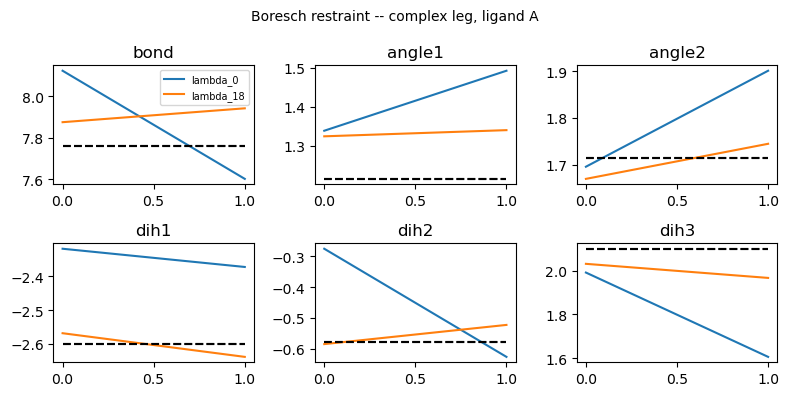

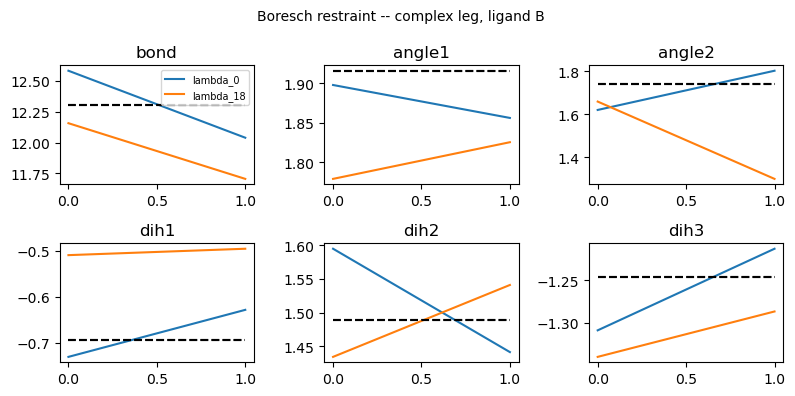

In [21]:
for ligand in ("A", "B"):
    geom_key = f"restraint_geometry_{ligand}"
    if geom_key not in complex_setup_outputs:
        print(f"No {geom_key} found, skipping ligand {ligand}")
        continue

    geom = complex_setup_outputs[geom_key]
    host_atoms_full = geom["host_atoms"]
    guest_atoms_full = geom["guest_atoms"]

    host_atoms = translate_to_subsampled_indices(host_atoms_full, selection_indices)
    guest_atoms = translate_to_subsampled_indices(guest_atoms_full, selection_indices)

    # Reference values: bond is stored in nm, convert to Angstrom to match
    # calc_bonds' output units; angles/dihedrals are already in radians.
    reference_values = [
        geom["r_aA0"]["val"] * 10,
        geom["theta_A0"]["val"],
        geom["theta_B0"]["val"],
        geom["phi_A0"]["val"],
        geom["phi_B0"]["val"],
        geom["phi_C0"]["val"],
    ]

    fig = plot_boresch_restraint(
        septop_complex_nc_file,
        septop_complex_pdb,
        lambda_windows,
        host_atoms,
        guest_atoms,
        reference_values,
        ligand_label=f"complex leg, ligand {ligand}",
    )
    plt.show()

## What to look for

For a well-behaved restraint, each quantity (bond, angle1, angle2, dih1,
dih2, dih3) should fluctuate **around** its dashed reference line, for
*both* the first and last lambda window. If a quantity sits at a
consistent offset from the reference line rather than fluctuating around
it, that's worth investigating.